# Eksperimen_Teo-Prayoga-Kartika
## Proyek Akhir: Membangun Sistem Machine Learning
### Dataset: Wine Quality

**Nama Siswa:** Teo Prayoga Kartika
**Platform:** Dicoding Indonesia
**Kelas:** Membangun Sistem Machine Learning (SMSML)

---


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Library berhasil diimport!
Pandas version: 2.3.3
NumPy version: 2.2.6


## 2. Data Loading

Memuat dataset Wine Quality yang berisi informasi kimiawi dari sampel anggur merah beserta labelnya (tipe wine: 0, 1, 2).


In [2]:
# Load dataset
df = pd.read_csv('../winequality_raw/winequality_raw.csv')

print(f"Dataset berhasil dimuat!")
print(f"Shape dataset: {df.shape}")
print(f"\nInformasi kolom:")
print(df.dtypes)


Dataset berhasil dimuat!
Shape dataset: (178, 14)

Informasi kolom:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object


In [3]:
# Tampilkan beberapa baris pertama
print("5 baris pertama dataset:")
df.head()


5 baris pertama dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# Tampilkan informasi dataset
print("Informasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null   

## 3. Exploratory Data Analysis (EDA)

Pada tahap ini kita akan mengeksplorasi dataset untuk memahami distribusi data, korelasi antar fitur, dan potensi anomali.


In [5]:
# Statistik deskriptif
print("Statistik Deskriptif Dataset:")
df.describe().round(2)


Statistik Deskriptif Dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


In [6]:
# Cek missing values
print("Jumlah Missing Values per Kolom:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


Jumlah Missing Values per Kolom:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Total missing values: 0


Distribusi Target (Tipe Wine):
target
1    71
0    59
2    48
Name: count, dtype: int64

Proporsi:
target
1    0.399
0    0.331
2    0.270
Name: proportion, dtype: float64


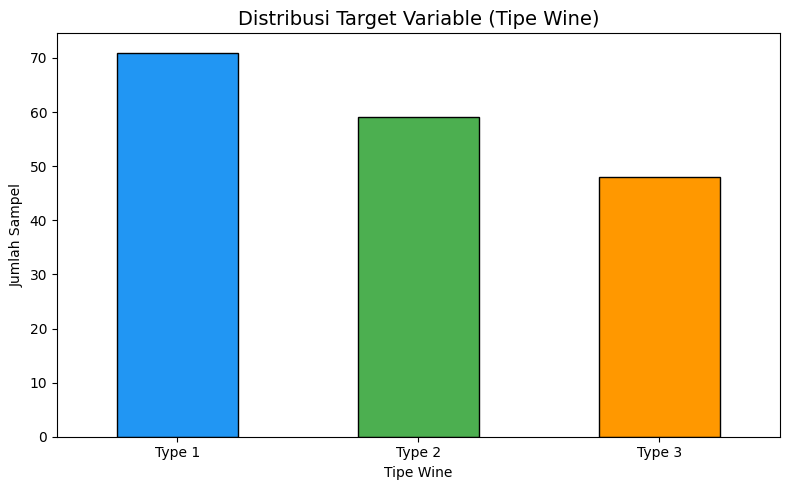

Plot disimpan.


In [7]:
# Distribusi target variable
print("Distribusi Target (Tipe Wine):")
print(df['target'].value_counts())
print(f"\nProporsi:")
print(df['target'].value_counts(normalize=True).round(3))

plt.figure(figsize=(8, 5))
target_names = ['Class 0 (Type 1)', 'Class 1 (Type 2)', 'Class 2 (Type 3)']
df['target'].value_counts().plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black')
plt.title('Distribusi Target Variable (Tipe Wine)', fontsize=14)
plt.xlabel('Tipe Wine')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=[0,1,2], labels=['Type 1', 'Type 2', 'Type 3'], rotation=0)
plt.tight_layout()
plt.savefig('../preprocessing/eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot disimpan.")


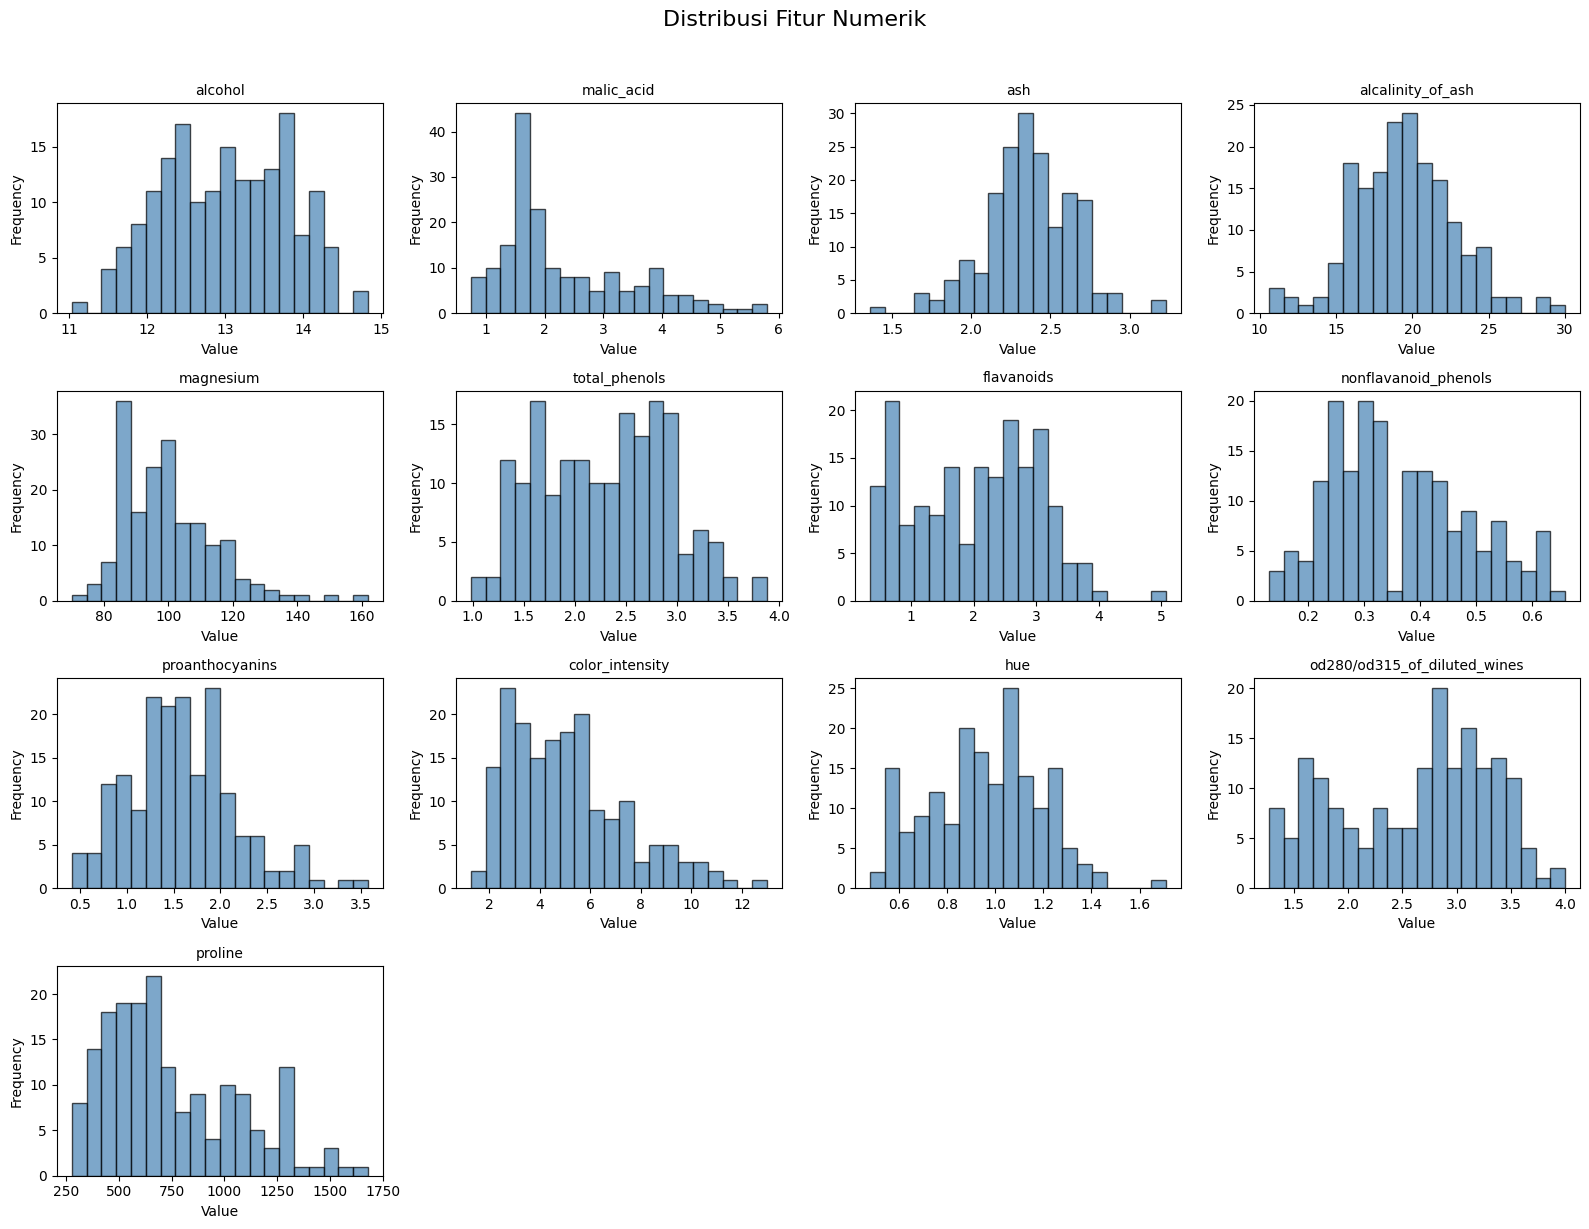

Plot disimpan.


In [8]:
# Distribusi fitur numerik
feature_cols = [c for c in df.columns if c != 'target']
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Sembunyikan axes yang tidak terpakai
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../preprocessing/eda_feature_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot disimpan.")


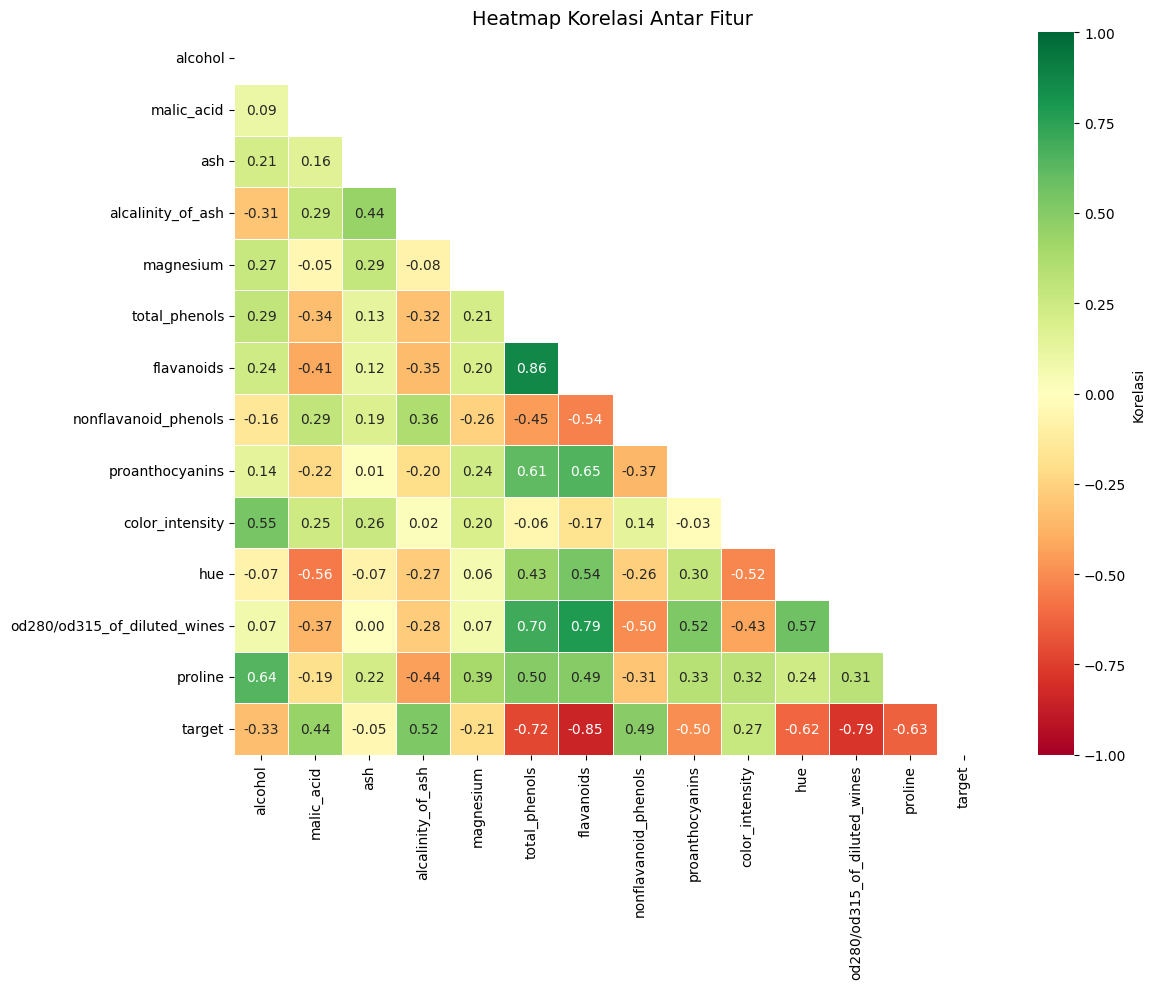

Heatmap disimpan.


In [9]:
# Heatmap korelasi
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            cbar_kws={'label': 'Korelasi'})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('../preprocessing/eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("Heatmap disimpan.")


In [10]:
# Deteksi Outlier menggunakan IQR
print("Deteksi Outlier (IQR Method):")
outlier_info = {}
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outlier_info[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_info, orient='index', columns=['Jumlah Outlier'])
print(outlier_df)


Deteksi Outlier (IQR Method):
                              Jumlah Outlier
alcohol                                    0
malic_acid                                 3
ash                                        3
alcalinity_of_ash                          4
magnesium                                  4
total_phenols                              0
flavanoids                                 0
nonflavanoid_phenols                       0
proanthocyanins                            2
color_intensity                            4
hue                                        1
od280/od315_of_diluted_wines               0
proline                                    0


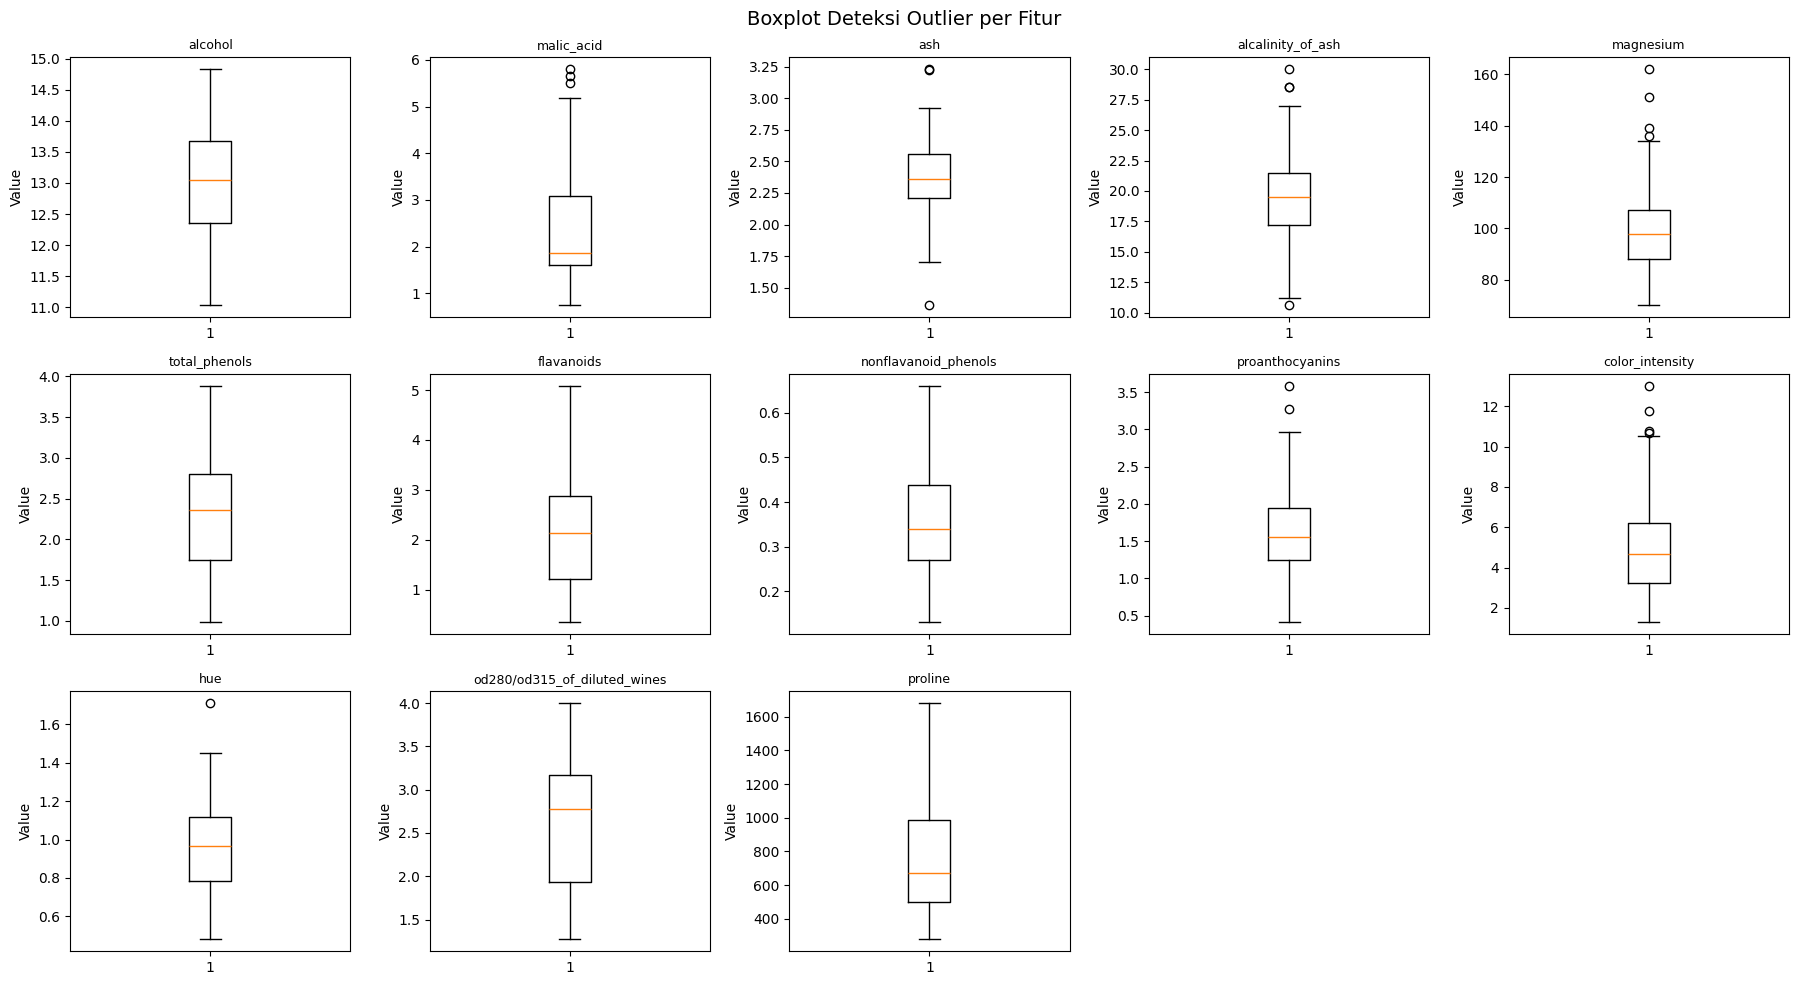

Boxplot disimpan.


In [11]:
# Boxplot untuk visualisasi outlier
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Value')

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Deteksi Outlier per Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('../preprocessing/eda_boxplot_outliers.png', dpi=100, bbox_inches='tight')
plt.show()
print("Boxplot disimpan.")


## 4. Data Preprocessing

Tahap preprocessing meliputi:
1. Penanganan missing values (jika ada)
2. Penanganan outlier (capping/clipping)
3. Feature scaling (StandardScaler)
4. Train-Test Split


In [12]:
# 4.1 Penanganan Missing Values
print("Penanganan Missing Values...")
df_clean = df.copy()

# Cek missing values
if df_clean.isnull().sum().sum() == 0:
    print("Tidak ada missing values. Dataset sudah bersih.")
else:
    # Isi dengan median untuk kolom numerik
    for col in feature_cols:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    print("Missing values berhasil ditangani dengan median.")

print(f"Shape setelah penanganan missing values: {df_clean.shape}")


Penanganan Missing Values...
Tidak ada missing values. Dataset sudah bersih.
Shape setelah penanganan missing values: (178, 14)


In [13]:
# 4.2 Penanganan Outlier dengan IQR Capping
print("Penanganan Outlier dengan IQR Capping...")

df_no_outlier = df_clean.copy()

for col in feature_cols:
    Q1 = df_no_outlier[col].quantile(0.25)
    Q3 = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outlier[col] = df_no_outlier[col].clip(lower=lower, upper=upper)

print(f"Shape setelah penanganan outlier: {df_no_outlier.shape}")
print("Outlier berhasil di-cap menggunakan metode IQR.")


Penanganan Outlier dengan IQR Capping...
Shape setelah penanganan outlier: (178, 14)
Outlier berhasil di-cap menggunakan metode IQR.


In [14]:
# 4.3 Pemisahan Fitur dan Target
X = df_no_outlier.drop('target', axis=1)
y = df_no_outlier['target']

print(f"Shape X (fitur): {X.shape}")
print(f"Shape y (target): {y.shape}")
print(f"\nDistribusi kelas target:")
print(y.value_counts())


Shape X (fitur): (178, 13)
Shape y (target): (178,)

Distribusi kelas target:
target
1    71
0    59
2    48
Name: count, dtype: int64


In [15]:
# 4.4 Feature Scaling dengan StandardScaler
print("Feature Scaling dengan StandardScaler...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Statistik sebelum scaling:")
print(X.describe().round(2).loc[['mean', 'std']].T.head(5))
print("\nStatistik setelah scaling:")
print(X_scaled.describe().round(4).loc[['mean', 'std']].T.head(5))


Feature Scaling dengan StandardScaler...
Statistik sebelum scaling:
                    mean    std
alcohol            13.00   0.81
malic_acid          2.33   1.10
ash                 2.37   0.26
alcalinity_of_ash  19.48   3.29
magnesium          99.48  13.41

Statistik setelah scaling:
                   mean     std
alcohol            -0.0  1.0028
malic_acid          0.0  1.0028
ash                -0.0  1.0028
alcalinity_of_ash  -0.0  1.0028
magnesium          -0.0  1.0028


In [16]:
# 4.5 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test:  {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test:  {y_test.shape}")
print(f"\nProporsi kelas pada train set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nProporsi kelas pada test set:")
print(y_test.value_counts(normalize=True).round(3))


Shape X_train: (142, 13)
Shape X_test:  (36, 13)
Shape y_train: (142,)
Shape y_test:  (36,)

Proporsi kelas pada train set:
target
1    0.401
0    0.331
2    0.268
Name: proportion, dtype: float64

Proporsi kelas pada test set:
target
1    0.389
0    0.333
2    0.278
Name: proportion, dtype: float64


In [17]:
# 4.6 Simpan hasil preprocessing
import os
os.makedirs('../preprocessing/winequality_preprocessing', exist_ok=True)

# Simpan train dan test set
X_train.to_csv('../preprocessing/winequality_preprocessing/X_train.csv', index=False)
X_test.to_csv('../preprocessing/winequality_preprocessing/X_test.csv', index=False)
y_train.to_csv('../preprocessing/winequality_preprocessing/y_train.csv', index=False)
y_test.to_csv('../preprocessing/winequality_preprocessing/y_test.csv', index=False)

# Simpan dataset yang sudah diproses (gabungan)
df_preprocessed = X_scaled.copy()
df_preprocessed['target'] = y.values
df_preprocessed.to_csv('../preprocessing/winequality_preprocessing/winequality_preprocessed.csv', index=False)

print("Dataset preprocessing berhasil disimpan!")
print("File yang disimpan:")
for f in os.listdir('../preprocessing/winequality_preprocessing'):
    print(f"  - {f}")


Dataset preprocessing berhasil disimpan!
File yang disimpan:


  - X_train.csv
  - y_train.csv
  - winequality_preprocessed.csv
  - y_test.csv
  - X_test.csv


## 5. Kesimpulan

Pada tahap eksperimen ini, telah dilakukan beberapa tahapan penting:

### Hasil EDA:
- Dataset Wine Quality memiliki **178 sampel** dengan **13 fitur** numerik dan **1 target** (tipe wine: 0, 1, 2)
- Distribusi kelas: Type 1 (59 sampel), Type 2 (71 sampel), Type 3 (48 sampel)
- Tidak ditemukan **missing values** pada dataset
- Beberapa fitur memiliki **outlier** yang telah ditangani dengan metode IQR capping
- Terdapat **korelasi tinggi** antara beberapa fitur kimia wine

### Tahapan Preprocessing:
1. ✅ **Data Loading** - Dataset berhasil dimuat
2. ✅ **EDA** - Distribusi, korelasi, dan outlier telah dianalisis
3. ✅ **Penanganan Outlier** - Menggunakan IQR capping
4. ✅ **Feature Scaling** - StandardScaler diterapkan
5. ✅ **Train-Test Split** - 80% train, 20% test dengan stratifikasi

### Output Preprocessing:
- `winequality_preprocessing/X_train.csv` - 142 sampel training
- `winequality_preprocessing/X_test.csv` - 36 sampel testing
- `winequality_preprocessing/y_train.csv` - Label training
- `winequality_preprocessing/y_test.csv` - Label testing
- `winequality_preprocessing/winequality_preprocessed.csv` - Dataset lengkap

Dataset siap digunakan untuk tahap pelatihan model.
